In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import numpy as np
import scipy
import pandas as pd
from scipy.stats import pearsonr, zscore

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from PSN.psn import psn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import r2_score

import imageio.v2 as imageio
import torch
import torch.nn.functional as F
from torchvision import transforms

from transformers import CLIPVisionModelWithProjection, CLIPImageProcessor

from utils import align_channels_across_runs, compute_ncsnr_all_timepoints, reshape_electrode_data_by_stimuli, extract_images_with_n_repeats, ncsnr_figs

# Set random seed for reproducibility
np.random.seed(42)

/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
base_dir = '/home/ri99/ieeg'
ieeg_dir = f'{base_dir}/subjects/111'
csv_dir = f'{base_dir}/nsd_PTB'
img_dir = f'{base_dir}/nsd_ecog'
cache_dir = f'{base_dir}/.cache'
os.makedirs(cache_dir, exist_ok=True)
sub = 11
n_blocks = -1  # -1 = use all blocks
n_runs = 56

sampling_rate = 1024  # Hz
baseline_time = 0.2  # seconds of data per trial before stimulus onset
# subject 111 had 5600 images split into 4 distinct sessions over 2 days (day 1: runs 1-12 and 13-24; day 2: runs 25-36 and 37-56)

In [8]:
curric = pd.read_csv(f"{csv_dir}/curriculum_patient{sub}.csv")
# labels = metapath_df['Destrieux_label_text'].values
curric.head()

,Unnamed: 0,filename,inventory,coco_id,is_repeat,repetition_number,block
0,0,special_23715.png,1x-shared1000_A,23715.0,0,1,1
1,1,notspecial_24264.png,1x-shared1000_A,24264.0,0,1,1
2,2,pair_45_w_pagoda1.png,MST,NaN,0,1,1
3,3,pair_33_nsd_777_1_cocoid_68844.png,MST,68844.0,0,1,1
4,4,notspecial_36682.png,3x-shared1000_A,36682.0,0,1,1


In [9]:
if n_blocks == -1:  # use all available blocks
    block_list = curric['block'].unique().astype(str)
else:  # use n_blocks to specify instead
    block_list = [str(x) for x in range(1, n_blocks+1)]

print(block_list)
image_names = list(curric[curric['block'].isin(block_list)]['filename'])
print(len(image_names))

['1' '2' '3' '4' 'filler_block_1' 'filler_block_2']
5600


In [13]:
# load bipolar-referenced voltage trace data (no frequency decomposition) at 1024Hz

run_list = list(range(1, n_runs+1))

all_data = []
all_labels = []
time_ref = None

for run in tqdm(run_list):
    data = np.load(f"{ieeg_dir}/bandpower1024/npy/sub1{sub}_NSD_run{run}_bandpower70-170.npy")
    labels = pd.read_csv(f"{ieeg_dir}/bandpower1024/ch_labels/sub1{sub}_NSD_run{run}_bandpower_channels.csv")
    time = np.load(f"{ieeg_dir}/bandpower1024/time/sub1{sub}_NSD_run{run}_bandpower_time.npy")

    assert time.shape[0] == data.shape[2], f"time mismatch in run {run}"
    assert labels.shape[0] == data.shape[1], f"label mismatch in run {run}"

    # assert labels['channel_name'].iloc[168] == 'ECG1'
    
    if time_ref is None:
        time_ref = time
    else:
        assert np.allclose(time, time_ref), f"time array differs in run {run}"

    all_data.append(data)
    all_labels.append(labels)

print(len(all_data))

100%|██████████| 56/56 [00:16<00:00,  3.46it/s]


In [14]:
# combine data across runs while dealing with some runs not having data from the same channels
data, channel_info = align_channels_across_runs(all_data, all_labels)
data = data.transpose(1,2,0).astype(np.float16)  # convert to channels x time x trials
print(f"Final shape: {data.shape}")
print(channel_info.head())

Aligning runs: 100%|██████████| 56/56 [00:09<00:00,  6.16it/s]



Channels with missing data (not present in all runs): ['LAP-pC_2-1', 'LmF-aI_6-5', 'LmF-aI_7-6', 'LsT-HC_2-1', 'LsT-HC_3-2', 'LsT-HC_5-4', 'LsT-HC_6-5', 'LsT-HC_8-7', 'LsT-Pu_6-5', 'LsT-Pu_7-6', 'LsT-Pu_8-7', 'RSP-pC_11-10', 'RSP-pC_12-11', 'RSP-pC_5-4', 'RSP-pC_6-5', 'RSP-pC_8-7', 'RSP-pC_9-8', 'RmF-aI_10-9', 'RmF-aI_11-10', 'RmF-aI_12-11', 'RmF-aI_6-5', 'RmF-oF_5-4', 'RmF-oF_8-7']
Final shape: (130, 2049, 5600)
   channel_name  channel_idx
0   LAP-pC_10-9            8
1  LAP-pC_11-10            9
2  LAP-pC_12-11           10
3    LAP-pC_2-1            0
4    LAP-pC_3-2            1


In [9]:
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
#     display(channel_info)
# print(labels.iloc[124:130])

# reshape to identify repeated stimuli

In [15]:
# First, reshape your electrode data using the existing function
reshaped_electrode_data, stim_info = reshape_electrode_data_by_stimuli(
    data,  # Your electrode data (channels, time, trials)
    curric,         # Your events dataframe
    stim_column='coco_id'
)

Original electrode data shape: (130, 2049, 5600)
Events dataframe shape: (5600, 7)
Number of unique stimuli: 2900
Maximum repetitions per stimulus: 4
Repetition distribution:
count
1     800
2    1600
3     400
4     100
Name: count, dtype: int64


100%|██████████| 2900/2900 [00:01<00:00, 2110.42it/s]

Final reshaped data shape: (130, 2900, 2049, 4)
Shape interpretation: (130 channels, 2900 images, 2049 timepoints, 4 max repeats)


In [16]:
# # Then extract images with exactly 6 repeats
# filtered_3_repeats, stimuli_3_repeats, indices_3_repeats = extract_images_with_n_repeats(
#     reshaped_electrode_data, 
#     stim_info, 
#     n_repeats=3
# )

# # Check the result
# print(f"Filtered data shape: {filtered_3_repeats.shape}")
# print(f"Number of stimuli with 3 repeats: {len(stimuli_3_repeats)}")

# filtered_3_repeats = filtered_3_repeats
# filtered_chan_labels = labels

# print(filtered_3_repeats.shape)

In [17]:
# # Check if bad channels have ALL NaNs in the 3-repeat subset
# bad_channels = [57, 58, 60, 61, 63, 68, 69, 70, 78, 79, 85, 86]

# print("Checking 3-repeat images:")
# for ch in bad_channels:
#     ch_data = filtered_3_repeats[ch, :, :, :]
#     print(f"Channel {ch}: {np.isnan(ch_data).all()} (all NaN?), "
#           f"{np.isnan(ch_data).sum()}/{ch_data.size} NaNs")

# # Now check if they have data for OTHER repeat counts
# print("\nChecking other images (not 3-repeat):")
# # Get indices of images that DON'T have 3 repeats
# all_indices = np.arange(2900)
# not_3_repeat_mask = ~np.isin(all_indices, indices_3_repeats)

# for ch in bad_channels:
#     ch_other_data = reshaped_electrode_data[ch, not_3_repeat_mask, :, :]
#     non_nan = (~np.isnan(ch_other_data)).sum()
#     print(f"Channel {ch}: {non_nan} non-NaN values in non-3-repeat images")

# measure NCSNR and noise ceiling pct over time to identify electrodes with good signal 

In [18]:
# nt = filtered_3_repeats.shape[2]

In [19]:
# The filtered_6_repeats has shape (channels, n_filtered_images, time, n_repeats)
# We need to transpose it to (conditions, channels, trials, timepoints) for the noise ceiling function
# print(f"Original filtered data shape: {filtered_3_repeats.shape}")
# Transpose from (channels, images, time, repeats) to (images, channels, repeats, time)
# data_rep = filtered_3_repeats.transpose(1, 0, 3, 2)
data_rep = reshaped_electrode_data.transpose(1, 0, 3, 2)
data_slim = data_rep[:,:,:]
print(f"Transposed data shape: {data_slim.shape}")
print(f"Shape interpretation: ({data_slim.shape[0]} conditions/images, {data_slim.shape[1]} channels, {data_slim.shape[2]} trials/repeats, {data_slim.shape[3]} timepoints)")

# Compute NCSNR for all timepoints
ncsnr_all, nc_all = compute_ncsnr_all_timepoints(data_slim, time)

rankings = np.flip(np.argsort(ncsnr_all.mean(1)))
# Visualize the results
ncsnr_figs(ncsnr_all[rankings[:100]], nc_all[rankings[:100]], time)

Transposed data shape: (2900, 130, 4, 2049)
Shape interpretation: (2900 conditions/images, 130 channels, 4 trials/repeats, 2049 timepoints)
Computing NCSNR for 130 channels across 2049 timepoints...
Processing timepoint 1/2049 (0.0ms)


/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/utils.py:117: RuntimeWarning: Degrees of freedom <= 0 for slice.
  trial_var = np.nanvar(data_in, axis=2, ddof=1)
/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/utils.py:121: RuntimeWarning: Mean of empty slice
  data_var = np.nanvar(np.nanmean(data_in, axis=2), axis=1, ddof=1)
/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/utils.py:124: RuntimeWarning: divide by zero encountered in divide
  n_eff_inv = np.nanmean(np.where(n_per_cond > 0, 1.0 / n_per_cond, np.nan), axis=1)  # (channels,)


KeyboardInterrupt: 

In [20]:
# calculate average response of each channel
print(reshaped_electrode_data.shape)

# baseline_start_idx = int(np.floor(baseline_time+0.2 * sampling_rate))  # baseline duration (sec; -0.2-0.2sec post stim onset) * sampling rate (1/sec)
# baseline_mean = np.mean(reshaped_electrode_data[:,:,:baseline_start_idx,:], axis=2)
# avg_signal = reshaped_electrode_data - baseline_mean[:,:,np.newaxis,:]  # baseline subtract per trial
avg_signal = reshaped_electrode_data

avg_signal = np.nanmean(avg_signal, axis=3)  # average over repeats
avg_signal = np.nanmean(avg_signal, axis=1)  # average over conditions

print(avg_signal.shape)

(130, 2900, 2049, 4)


/tmp/ipykernel_3798858/2713222521.py:9: RuntimeWarning: Mean of empty slice
  avg_signal = np.nanmean(avg_signal, axis=3)  # average over repeats


(130, 2049)


Plotting...


100%|██████████| 130/130 [00:09<00:00, 14.20it/s]


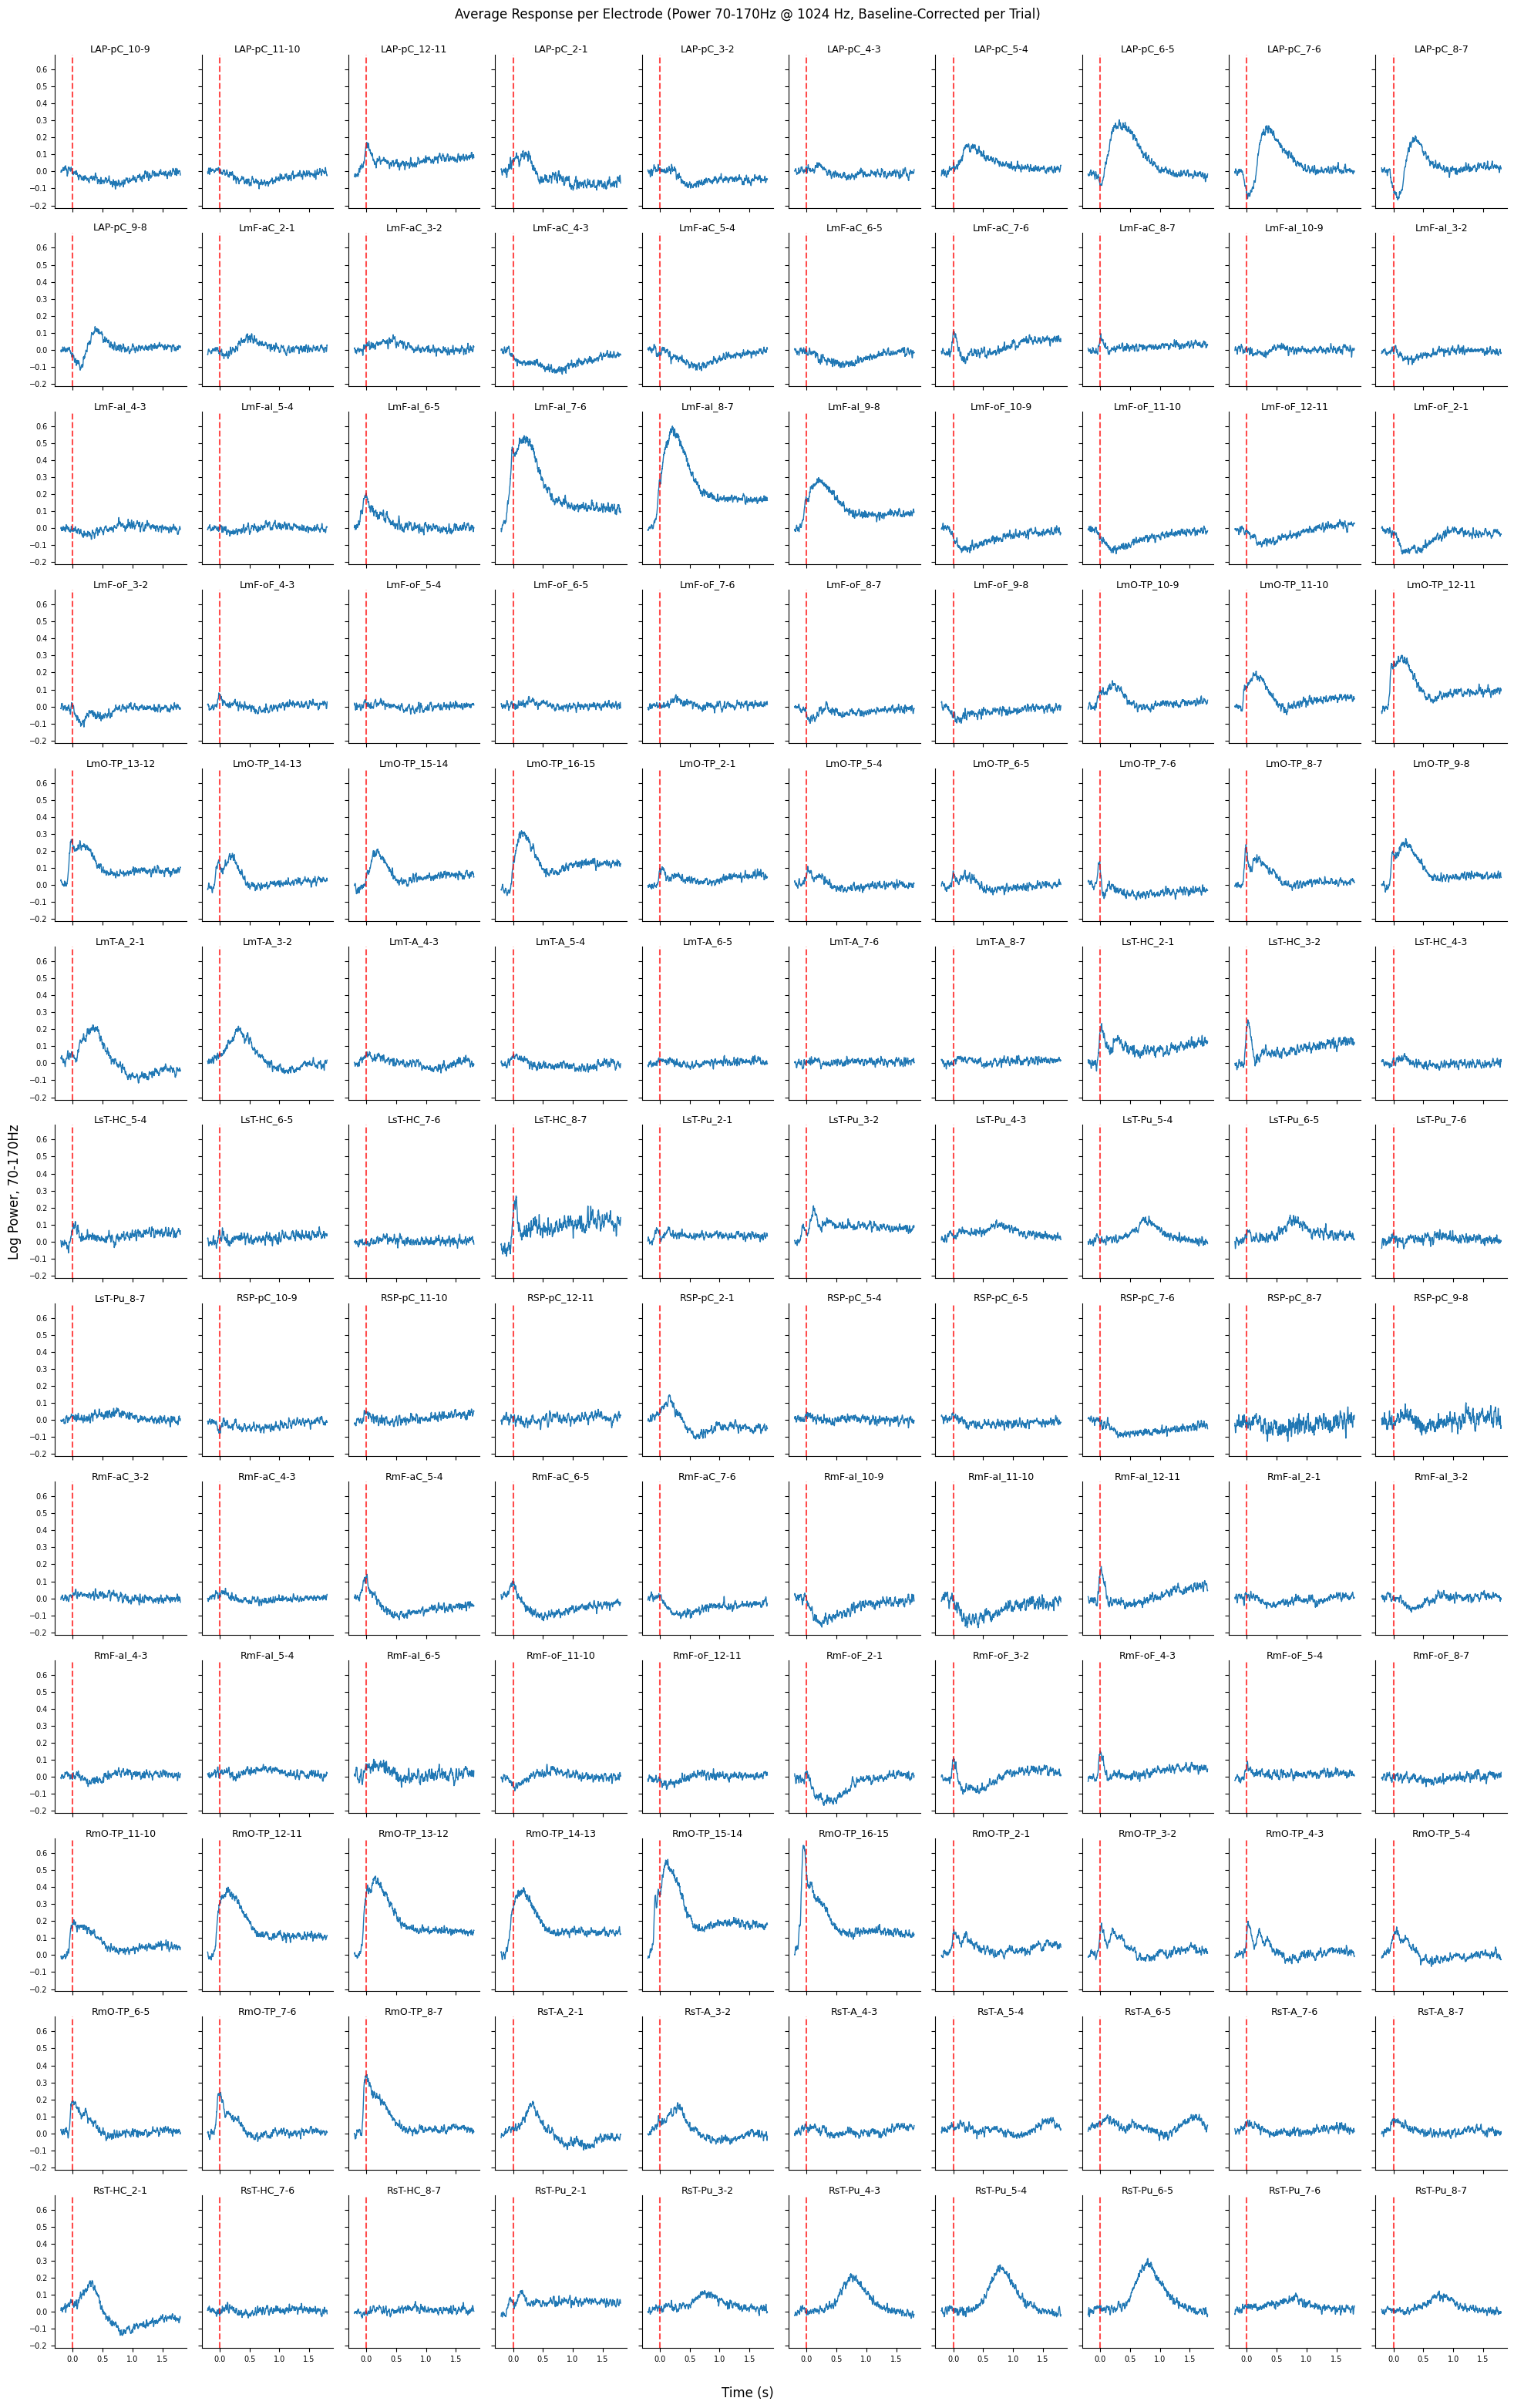

In [22]:
ncols = 10
nrows = int(np.ceil(len(avg_signal) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 32), sharex=True, sharey=True)
fig.suptitle(f'Average Response per Electrode (Power 70-170Hz @ {sampling_rate} Hz, Baseline-Corrected per Trial)')
fig.supxlabel('Time (s)')
fig.supylabel('Log Power, 70-170Hz')
axes_flat = axes.flatten()

print('Plotting...')
for i in tqdm(range(len(avg_signal))):
    ax = axes_flat[i]
    ax.plot((np.arange(avg_signal.shape[1])/sampling_rate)-baseline_time, avg_signal[i], linewidth=1)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    
    curr_label = channel_info.iloc[i]
    # if int(curr_label['channel_idx']) in rankings[:20]:
    #     ax.set_title(f"{curr_label['channel_name']}", fontsize=9, pad=2, color='red', fontweight='bold')
    # elif int(curr_label['channel_idx']) in rankings[20:50]:
    #     ax.set_title(f"{curr_label['channel_name']}", fontsize=9, pad=2, color='orange')
    # else:
    #     ax.set_title(f"{curr_label['channel_name']}", fontsize=9, pad=2)
    ax.set_title(f"{curr_label['channel_name']}", fontsize=9, pad=2)
    
    ax.tick_params(labelsize=7)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0.01, 0.01, 1, 0.98])
plt.savefig('avg_response_bandpower')
plt.show()

In [24]:
print(avg_signal.shape)
print(reshaped_electrode_data.shape)

(130, 2049)
(130, 2900, 2049, 4)


(2049, 2)


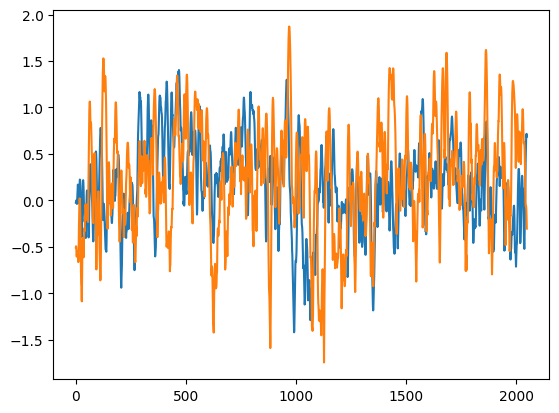

In [82]:
tmp = np.nanmean(reshaped_electrode_data[7,::2000,:], axis=-1).T
print(tmp.shape)
plt.plot(tmp)
plt.show()